# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
!pip install phik

     |████████████████████████████████| 677 kB 2.6 MB/s eta 0:00:01


In [2]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from phik import phik_matrix

In [3]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             } 

In [4]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [5]:
engine = create_engine(connection_string)

In [6]:
with engine.begin() as conn:
    conn.execute("SELECT set_config('synchronize_seqscans', 'off', true);")


query = '''SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    (p.created_ts_msk-LAG(p.created_ts_msk) OVER (PARTITION BY p.user_id ORDER BY p.user_id, p.created_ts_msk)) AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases AS p
JOIN afisha.events AS e USING(event_id)
LEFT JOIN afisha.city AS c USING(city_id)
LEFT JOIN afisha.regions AS r USING(region_id)
WHERE p.device_type_canonical IN ('mobile', 'desktop') AND e.event_type_main != 'фильм'
ORDER BY p.user_id
'''

In [7]:
df = pd.read_sql_query(query, con=engine)

In [8]:
df['user_id'].nunique()

21933

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype          
---  ------                 --------------   -----          
 0   user_id                290611 non-null  object         
 1   device_type_canonical  290611 non-null  object         
 2   order_id               290611 non-null  int64          
 3   order_dt               290611 non-null  datetime64[ns] 
 4   order_ts               290611 non-null  datetime64[ns] 
 5   currency_code          290611 non-null  object         
 6   revenue                290611 non-null  float64        
 7   tickets_count          290611 non-null  int64          
 8   days_since_prev        268678 non-null  timedelta64[ns]
 9   event_id               290611 non-null  int64          
 10  event_name             290611 non-null  object         
 11  event_type_main        290611 non-null  object         
 12  service_name           290611 

* В выгрузке 290611 строк, 15 столбцов.
* Информация представлена 5 типами данных: datetime64[ns] (2), float64(1), int64(3), object(8), timedelta64[ns] (1).
* Пропуски представлены в столбце days_since_prev, вызваны наличием пользователей совершивших только один заказ.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [10]:
kurs_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
kurs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Для совместимости между двумя таблицами, преобразуем данные поля 'data':

In [11]:
kurs_df['data'] = pd.to_datetime(kurs_df['data'])

In [12]:
df = df.merge(kurs_df, left_on='order_dt', right_on='data', how='left')

Пересчитаем выручку в рубли для всех заказов:

In [13]:
df['revenue_rub'] = df.apply(
    lambda row: row['revenue'] if row['currency_code'] == 'RUB' 
    else (row['revenue'] * row['curs'] / 100), 
    axis=1
)

In [14]:
df = df.drop(columns=['data', 'curs'])

In [15]:
df[['currency_code', 'revenue', 'revenue_rub']].head(10)

,currency_code,revenue,revenue_rub
0,rub,1521.94,284.560166
1,rub,289.45,53.090630
2,rub,1258.57,247.277541
3,rub,8.49,1.570735
4,rub,1390.41,273.421346
5,rub,902.74,181.027355
6,rub,917.83,172.304226
7,rub,47.78,9.256945
8,rub,74.84,14.757325
9,rub,1421.91,256.539580


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

Как упоминалось выше, пропуски обнаружены только в столбце `days_since_prev`.

Оптимизируем использование памяти для числовых столбцов:

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype          
---  ------                 --------------   -----          
 0   user_id                290611 non-null  object         
 1   device_type_canonical  290611 non-null  object         
 2   order_id               290611 non-null  int64          
 3   order_dt               290611 non-null  datetime64[ns] 
 4   order_ts               290611 non-null  datetime64[ns] 
 5   currency_code          290611 non-null  object         
 6   revenue                290611 non-null  float64        
 7   tickets_count          290611 non-null  int64          
 8   days_since_prev        268678 non-null  timedelta64[ns]
 9   event_id               290611 non-null  int64          
 10  event_name             290611 non-null  object         
 11  event_type_main        290611 non-null  object         
 12  service_name           290611 

In [17]:
int_columns_to_optimize = ['order_id', 'event_id', 'tickets_count', 'nominal']

for col in int_columns_to_optimize:
    df[col] = pd.to_numeric(df[col], downcast='integer')

Проверим, какие данные представлены в текстовых полях:

In [18]:
nominal_cols = [
    'device_type_canonical', 'currency_code', 'event_name', 
    'event_type_main', 'service_name', 'region_name', 'city_name'
]

for col in nominal_cols:
    display(df[col].unique())

array(['mobile', 'desktop'], dtype=object)

array(['rub', 'kzt'], dtype=object)

array(['f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad',
       '40efeb04-81b7-4135-b41f-708ff00cc64c',
       '01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca', ...,
       'cf71bf2b-8e5c-47e0-a0f3-c2d4910c4677',
       'f17a01b7-3cd3-4cd1-919c-3459bd074886',
       '0fd6df8e-49e5-4337-954d-5a4606b1b899'], dtype=object)

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'ёлки'], dtype=object)

array(['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!',
       'Билеты без проблем', 'Облачко', 'Лучшие билеты', 'Прачечная',
       'Быстробилет', 'Дом культуры', 'Весь в билетах', 'Билеты в руки',
       'Тебе билет!', 'Show_ticket', 'Городской дом культуры', 'Яблоко',
       'Билет по телефону', 'Выступления.ру', 'Росбилет',
       'Шоу начинается!', 'Мир касс', 'Восьмёрка', 'Телебилет',
       'Crazy ticket!', 'Реестр', 'Быстрый кассир', 'КарандашРУ',
       'Радио ticket', 'Дырокол', 'Вперёд!', 'Кино билет', 'Цвет и билет',
       'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете'],
      dtype=object)

array(['Каменевский регион', 'Североярская область', 'Озернинский край',
       'Лугоградская область', 'Поленовский край', 'Широковская область',
       'Медовская область', 'Златопольский округ', 'Малиновоярский округ',
       'Яблоневская область', 'Ветренский регион', 'Боровлянский край',
       'Крутоводская область', 'Ягодиновская область',
       'Серебряноярский округ', 'Лесодальний край', 'Верхоречная область',
       'Горицветская область', 'Речиновская область', 'Травиницкий округ',
       'Сосновская область', 'Серебринская область', 'Травяная область',
       'Каменноярский край', 'Солнечноземская область',
       'Светополянский округ', 'Заречная область', 'Ручейковский край',
       'Глиногорская область', 'Тепляковская область',
       'Каменноозёрный край', 'Солнечнореченская область',
       'Зоринский регион', 'Берёзовская область', 'Лесостепной край',
       'Малиновая область', 'Синегорский регион', 'Луговая область',
       'Шанырский регион', 'Каменополянский окр

array(['Глиногорск', 'Озёрск', 'Родниковецк', 'Кристалевск',
       'Дальнозолотск', 'Радужнополье', 'Радужсвет', 'Кумсай',
       'Верховино', 'Светополье', 'Кокжар', 'Каменский', 'Лесоярич',
       'Никольянов', 'Речинцево', 'Лесозолотск', 'Дальнозерск',
       'Серебрянка', 'Островецк', 'Родниковец', 'Дальнесветск',
       'Луговаярово', 'Ягодиновка', 'Дальнополин', 'Солчелуг', 'Озёрчане',
       'Серебровино', 'Лесоярово', 'Глинополье', 'Глиноград',
       'Дальнесветин', 'Северополье', 'Теплоозеро', 'Горнодолинск',
       'Ордакент', 'Озёрово', 'Луговинск', 'Лугоград', 'Златопольск',
       'Крутовинск', 'Сарыжар', 'Сосновечин', 'Тихоярск', 'Яблонецк',
       'Жаркентай', 'Широковка', 'Синеводов', 'Синеводск', 'Тихосветск',
       'Радужанов', 'Каменосветск', 'Глиногорь', 'Родниковск',
       'Травогород', 'Глинянск', 'Радужинск', 'Поляногорье',
       'Дальнолесье', 'Ручейник', 'Ключеград', 'Ключеводск', 'Поленовино',
       'Речичанск', 'Ключевополье', 'Шаныртау', 'Дальнесоснов'

Провдем нормализацию текстовых полей и проверим наличие неявных дубликатов:

In [19]:
for col in nominal_cols:
    df[col] = (df[col].astype(str)
                          .str.lower()
                          .str.strip()
                          .str.replace(r'\s+', ' ', regex=True))

In [20]:
for col in nominal_cols:
    display(df[col].value_counts().sort_index())

desktop     58121
mobile     232490
Name: device_type_canonical, dtype: int64

kzt      5069
rub    285542
Name: currency_code, dtype: int64

000a9c8d-65bb-4178-a5a8-9ddc1f3bf71e     5
0015b11d-a3e0-4656-887a-383450a9b313     2
00298e1a-ae90-482b-819d-ba88ceff59b0    15
002c06bc-a677-4f50-9873-836ca0658603    64
002d57b9-d9ca-46a9-a4be-7b5c8685832e    12
                                        ..
ffe19736-c5f5-477d-ada2-e97cae12c51e     2
ffed72f8-faf6-4784-af94-a9f82839a272     1
fff20f2b-de72-451a-8168-b765352e502c     2
fff68929-41eb-4dd7-90bf-76d3ae8b652f     1
fffd87ef-5469-4684-af21-4f9b86a13189     6
Name: event_name, Length: 15248, dtype: int64

выставки      4854
другое       65867
концерты    115276
спорт        21911
стендап      13393
театр        67321
ёлки          1989
Name: event_type_main, dtype: int64

crazy ticket!               790
show_ticket                2200
билет по телефону            85
билеты без проблем        63519
билеты в интернете            4
билеты в руки             40343
быстробилет                2003
быстрый кассир              381
весь в билетах            16849
восьмёрка                  1118
вперёд!                      80
выступления.ру             1616
городской дом культуры     2733
дом культуры               4502
дырокол                      74
за билетом!                2865
зе бест!                      5
карандашру                  133
кино билет                   67
край билетов               6207
лимоны                        8
лови билет!               41124
лучшие билеты             17774
мир касс                   2167
мой билет                 34839
облачко                   26642
прачечная                 10273
радио ticket                376
реестр                      125
росбилет                    539
тебе билет!                5228
телебиле

белоярская область        199
берестовский округ        395
берёзовская область      1282
боровлянский край        1721
верховинская область       50
                        ...  
шанырский регион         2882
широковская область     16457
яблоневская область      6181
ягодиновская область     1044
яснопольский округ         21
Name: region_name, Length: 81, dtype: int64

айкольск         2
айсуак           1
акбастау       193
акбасты        513
акжолтау        12
              ... 
ясногородин     26
ясноград       160
яснолесье       19
яснополянск     13
ясносветск      23
Name: city_name, Length: 352, dtype: int64

Значений, обозначающих пропуски в данных или отсутствие информации не обнаружено.

Сделаем обзор данных в полях 'revenue_rub', 'tickets_count':

In [21]:
df[['revenue_rub', 'tickets_count']].describe().round(2)

,revenue_rub,tickets_count
count,290611.00,290611.00
mean,120.30,2.75
std,238.47,1.17
min,-18.19,1.00
25%,22.57,2.00
50%,68.08,3.00
75%,155.52,4.00
max,15520.73,57.00


В поле 'revenue_rub' (выручка в руб.) обнаружены отрицательные значения. Посчитаем долю строк датафрейма с такими значениями:

In [22]:
(df[df['revenue_rub'] <= 0].shape[0] / df.shape[0]) * 100

2.0326140442034197

Около 2% данных имеют значения выручки <= 0, учитывая их незначительное количество отфильтруем такие данные на следующих шагах.

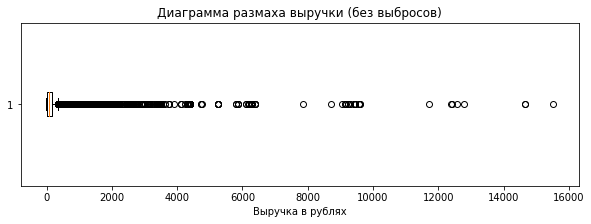

In [23]:
plt.figure(figsize=(10, 3))

plt.boxplot(df['revenue_rub'], 
            vert=False)

plt.title('Диаграмма размаха выручки (без выбросов)')
plt.xlabel('Выручка в рублях')
plt.show()


В поле revenue_rub наблюдаются выбросы в широкм диапазоне значений. Отфильтруем данные этого поля по 99 перцентюлю, как рекомендовано в задании:

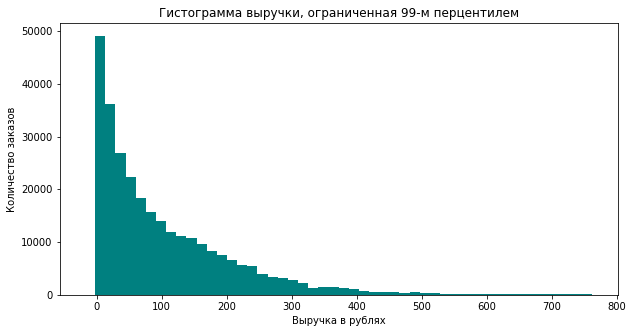

In [24]:
plt.figure(figsize=(10, 5))

plt.hist(df['revenue_rub'],
         bins=50, 
         color='teal', 
         range=(df['revenue_rub'].min(), df['revenue_rub'].quantile(0.99)))

plt.title('Гистограмма выручки, ограниченная 99-м перцентилем')
plt.xlabel('Выручка в рублях')
plt.ylabel('Количество заказов')
plt.show()

Теперь посмотрим на поле tickets_count:

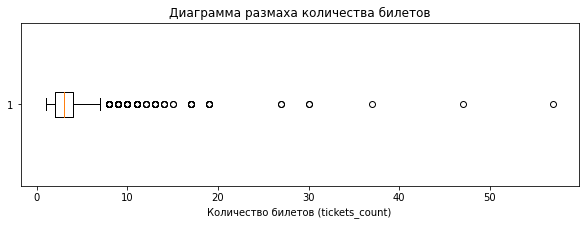

In [25]:
plt.figure(figsize=(10, 3))

plt.boxplot(df['tickets_count'], 
            vert=False)

plt.title('Диаграмма размаха количества билетов')
plt.xlabel('Количество билетов (tickets_count)')
plt.show()

В полен tickets_count наблюдаются выбросы. Попробуем отфильровать по 99 перцентилю:

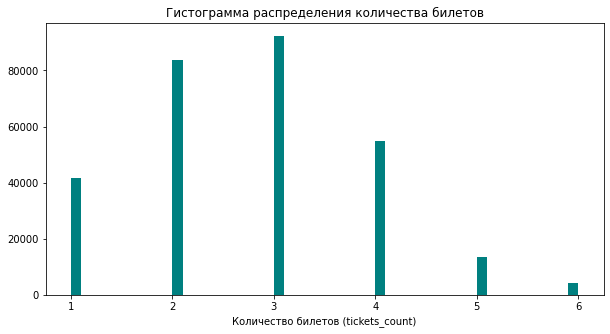

In [26]:
plt.figure(figsize=(10, 5))

plt.hist(df['tickets_count'], 
         bins=50, 
         color='teal', 
         range=(df['tickets_count'].min(), df['tickets_count'].quantile(0.99)))

plt.title('Гистограмма распределения количества билетов')
plt.xlabel('Количество билетов (tickets_count)')
plt.show()

Отфильтруем данные на основе выявленных аномалий:

In [27]:
df_clean = df[
    (df['revenue_rub'] >= 0) &
    (df['revenue_rub'] <= df['revenue_rub'].quantile(0.99)) &
    (df['tickets_count'] <= df['tickets_count'].quantile(0.99))
].copy()

В результате этого шага 
* Были оптимизированы используемый типы данных
* Данные о дате и времени оставлены без изменений
* В столбцах с номинальными данными не обнаружено ошибок и дублей
* Для важных численных данных (revenue_rub, tickets_count) обнаружены выбросы.
* В поле revenue_rub обнаружены отрицательные значения. 
* Данные отфильтрованы по 99 перцентилю для полей revenue_rub, tickets_count и по значению >=0 для поля revenue_rub

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [28]:
# Предварительная сортировка
df_clean = df_clean.sort_values(['user_id', 'order_ts'])

# В пределах пользователя посчитаем разницу дат между заказами 
df_clean['time_diff'] = df_clean.groupby('user_id')['order_ts'].diff()

Общая логика действий такая:
1. Создаем датафреймы для первого и последнего заказа пользователя на основе группировки по пользователю
2. Сделаем .merge() таблицы первых заказов с полями 'user_id', 'last_order' из таблицы последних заказов
3. Создаем датафрейм с агрегированными данными по каждому пользователю как требуется в задании
4. Сделаем .merge() таблицы с агрегированными данными по каждому пользователю с полями 'user_id', 'device_type_canonical', 'region_name', 'service_name', 'event_type_main', 'first_order', 'last_order' объедененной таблицы первых и посдледних заказов
5. Добавим бинарные признаки отдельными полями is_two и is_five

In [29]:
# Первый заказ
df_first = df_clean.drop_duplicates(subset=['user_id'], keep='first').copy()
df_first.rename(columns={'order_dt':'first_order'}, inplace=True)

# Последний заказ
df_last = df_clean.drop_duplicates(subset=['user_id'], keep='last').copy()
df_last.rename(columns={'order_dt':'last_order'}, inplace=True)

# Объеденим
df_first_last = df_first.merge(
    df_last[['user_id', 'last_order']], 
    on='user_id', 
    how='left'
)


In [30]:
# Посчитаем необходимые метрики из задания
profile = df_clean.groupby('user_id').agg(
    total_orders=('order_id', 'count'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean'),
    avg_time_diff=('time_diff', lambda x: x.mean())
).reset_index()

# Объеденим с таблицей первых и последних заказов
profile = profile.merge(
    df_first_last[['user_id', 'device_type_canonical', 'region_name', 
                  'service_name', 'event_type_main', 'first_order', 'last_order']],
    on='user_id',
    how='left'
)

# Переименуем некоторые поля для удобства
profile.rename(columns={
    'device_type_canonical': 'first_device',
    'region_name': 'first_region',
    'service_name': 'first_partner',
    'event_type_main': 'first_genre'
}, inplace=True)

In [31]:
profile['is_two'] = (profile['total_orders'] >= 2).astype(int)
profile['is_five'] = (profile['total_orders'] >= 5).astype(int)

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [32]:
total_users = profile['user_id'].nunique()
print(f"Общее число пользователей: {total_users}")

total_revenue_per_user = profile['total_orders'] * profile['avg_revenue_rub']
avg_revenue_per_order = total_revenue_per_user.sum() / profile['total_orders'].sum()
print(f"Средняя выручка с одного заказа: {avg_revenue_per_order:.2f} руб.")

share_two = profile['is_two'].mean() * 100
print(f"Доля пользователей с 2+ заказами: {share_two:.2f}%")

share_five = profile['is_five'].mean() * 100
print(f"Доля пользователей с 5+ заказами: {share_five:.2f}%")

Общее число пользователей: 21743
Средняя выручка с одного заказа: 103.24 руб.
Доля пользователей с 2+ заказами: 61.75%
Доля пользователей с 5+ заказами: 29.08%


In [33]:
print("Статистика по общему количеству заказов")
print(profile['total_orders'].describe(percentiles=[.25, .5, .75, .95, .99]))

print("\n Статистика по среднему количеству билетов в заказе")
print(profile['avg_tickets'].describe(percentiles=[.25, .5, .75, .95, .99]))

print("\n Статистика по среднему времени между заказами")
avg_days_clean = profile['avg_time_diff'].dropna()
print(avg_days_clean.describe(percentiles=[.25, .5, .75, .95, .99]))

Статистика по общему количеству заказов
count    21743.000000
mean        13.205905
std        121.945859
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
95%         32.000000
99%        151.580000
max      10179.000000
Name: total_orders, dtype: float64

 Статистика по среднему количеству билетов в заказе
count    21743.000000
mean         2.745037
std          0.910647
min          1.000000
25%          2.000000
50%          2.750000
75%          3.111111
95%          4.000000
99%          5.000000
max          6.000000
Name: avg_tickets, dtype: float64

 Статистика по среднему времени между заказами
count                         13426
mean     15 days 21:03:33.475352993
std      22 days 07:46:09.782366431
min                 0 days 00:00:01
25%       1 days 01:10:57.041666666
50%          8 days 02:50:21.600000
75%      20 days 12:56:14.946428571
95%         61 days 08:53:14.625000
99%               112 days 19:35:16
max               148 days

* Общее число пользователей: 21743
* Средняя выручка с одного заказа: 103.24 руб.
* Доля пользователей с 2+ заказами: 61.75%
* Доля пользователей с 5+ заказами: 29.08%
* В данных о количестве заказов имеются выбросы достигающие 10179. 
* Решено отфильтровать данные поля total_orders и avg_tickets по 99 перцентилю. Это не приведет к критичным потерям данных, но исключит влияние выбросов на статистические поазатели.

In [34]:
# Фильтруем данные по 99 перцентилю
filtered_profile = profile[
    (profile['total_orders'] <= profile['total_orders'].quantile(0.99)) &
    (profile['avg_tickets'] <= profile['avg_tickets'].quantile(0.99))
].copy()

print(f"\nОбъём данных оставшихся после фильтрации: {len(filtered_profile):,} пользователей из {total_users:,}")
print(f"Удалено пользователей: {total_users - len(filtered_profile):,} ({(1 - len(filtered_profile)/total_users)*100:.2f}%)")


Объём данных оставшихся после фильтрации: 21,336 пользователей из 21,743
Удалено пользователей: 407 (1.87%)


In [35]:
total_users = filtered_profile['user_id'].nunique()
print(f"Общее число пользователей: {total_users}")

total_revenue_per_user = filtered_profile['total_orders'] * filtered_profile['avg_revenue_rub']
avg_revenue_per_order = total_revenue_per_user.sum() / filtered_profile['total_orders'].sum()
print(f"Средняя выручка с одного заказа: {avg_revenue_per_order:.2f} руб.")

share_two = filtered_profile['is_two'].mean() * 100
print(f"Доля пользователей с 2+ заказами: {share_two:.2f}%")

share_five = filtered_profile['is_five'].mean() * 100
print(f"Доля пользователей с 5+ заказами: {share_five:.2f}%")

Общее число пользователей: 21336
Средняя выручка с одного заказа: 104.16 руб.
Доля пользователей с 2+ заказами: 61.63%
Доля пользователей с 5+ заказами: 28.57%


In [36]:
print("Статистика по общему количеству заказов")
print(filtered_profile['total_orders'].describe(percentiles=[.25, .5, .75, .95, .99]))

print("\n Статистика по среднему количеству билетов в заказе")
print(filtered_profile['avg_tickets'].describe(percentiles=[.25, .5, .75, .95, .99]))

print("\n Статистика по среднему времени между заказами")
avg_days_clean = filtered_profile['avg_time_diff'].dropna()
print(avg_days_clean.describe(percentiles=[.25, .5, .75, .95, .99]))

Статистика по общему количеству заказов
count    21336.000000
mean         6.530746
std         14.295335
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
95%         26.000000
99%         79.000000
max        151.000000
Name: total_orders, dtype: float64

 Статистика по среднему количеству билетов в заказе
count    21336.000000
mean         2.717670
std          0.870623
min          1.000000
25%          2.000000
50%          2.750000
75%          3.076923
95%          4.000000
99%          5.000000
max          5.000000
Name: avg_tickets, dtype: float64

 Статистика по среднему времени между заказами
count                          13149
mean      16 days 04:31:24.425606828
std       22 days 10:40:01.367584278
min                  0 days 00:00:01
25%                  1 days 10:34:33
50%           8 days 11:56:19.812500
75%       20 days 21:37:41.333333333
95%       62 days 00:59:57.199999997
99%      113 days 20:38:19.280000002
max              

* В результате этого шага объём данных оставшихся после фильтрации: 21,336 пользователей из 21,743.
* Удалено пользователей: 407 (1.87%), это допустимый объем потерь не приводящий к значимым искажениям дальнейшего анализа. 


---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [37]:
first_genre_group = filtered_profile['first_genre'].value_counts()
first_genre_group_share = filtered_profile['first_genre'].value_counts(normalize=True) * 100

genre_stats = pd.DataFrame({'Кол-во': first_genre_group, 'Доля %': first_genre_group_share.round(2)})
print("Группировка по типу первого мероприятия")
print(genre_stats.head(10))

Группировка по типу первого мероприятия
          Кол-во  Доля %
концерты    9315   43.66
другое      5379   25.21
театр       4249   19.91
стендап     1103    5.17
спорт        786    3.68
выставки     409    1.92
ёлки          95    0.45


In [38]:
first_device_group = filtered_profile['first_device'].value_counts()
first_device_group_share = filtered_profile['first_device'].value_counts(normalize=True) * 100

device_stats = pd.DataFrame({'Кол-во': first_device_group, 'Доля %': first_device_group_share.round(2)})
print("Группировка по типу устройства")
print(device_stats.head(10))

Группировка по типу устройства
         Кол-во  Доля %
mobile    17698   82.95
desktop    3638   17.05


In [39]:
first_region_group = filtered_profile['first_region'].value_counts()
first_region_group_share = filtered_profile['first_region'].value_counts(normalize=True) * 100

region_stats = pd.DataFrame({'Кол-во': first_region_group, 'Доля %': first_region_group_share.round(2)})
print("Группировка по региону")
print(region_stats.head(10))

Группировка по региону
                      Кол-во  Доля %
каменевский регион      7093   33.24
североярская область    3747   17.56
широковская область     1223    5.73
озернинский край         675    3.16
малиновоярский округ     537    2.52
травяная область         485    2.27
светополянский округ     466    2.18
речиновская область      438    2.05
яблоневская область      409    1.92
медовская область        370    1.73


In [40]:
first_partner_group = filtered_profile['first_partner'].value_counts()
first_partner_group_share = filtered_profile['first_partner'].value_counts(normalize=True) * 100

partner_stats = pd.DataFrame({'Кол-во': first_partner_group, 'Доля %': first_partner_group_share.round(2)})
print("Группировка по организатору")
print(partner_stats.head(10))

Группировка по организатору
                    Кол-во  Доля %
билеты без проблем    5104   23.92
лови билет!           2813   13.18
мой билет             2736   12.82
билеты в руки         2542   11.91
облачко               2184   10.24
весь в билетах        1294    6.06
лучшие билеты         1179    5.53
прачечная              589    2.76
край билетов           455    2.13
дом культуры           354    1.66


**Пользователи по сегментам распределены неравномерно, есть выраженные «точки входа»:**
* по типу мероприятия - это концерты  44.44%
* по типу устройства - это мобильные устройства 82.72%
* по региону - это каменевский регион 32.89%
* по организатору - это билеты без проблем 23.72%

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Вычислим долю повтроных покупок в зависимости от типа первого мероприятия

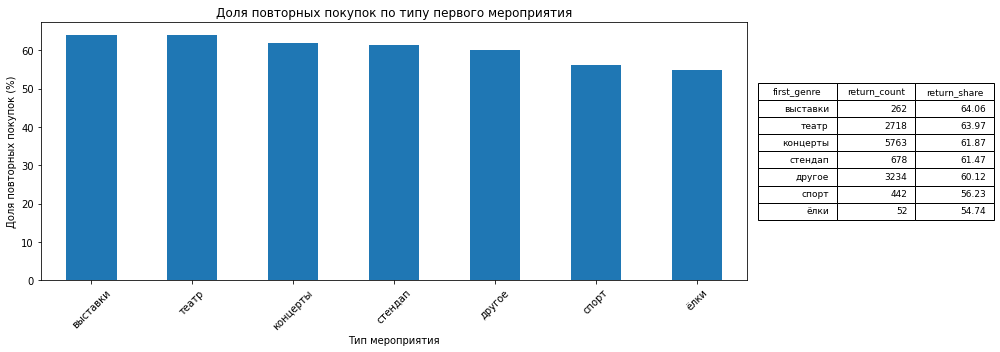

In [41]:
first_genre_group_is_two = filtered_profile.groupby('first_genre').agg(return_count=('is_two', 'sum'),
                                                return_share=('is_two', lambda x: round(x.mean() * 100, 2)))


genre_df = first_genre_group_is_two.sort_values('return_share', ascending=False).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2,
    figsize=(14, 5),
    gridspec_kw={'width_ratios': [3, 1]})


genre_df.plot(
    kind='bar',
    x='first_genre',
    y='return_share',
    ax=ax1,
    legend=False)

ax1.set_title('Доля повторных покупок по типу первого мероприятия')
ax1.set_xlabel('Тип мероприятия')
ax1.set_ylabel('Доля повторных покупок (%)')
ax1.tick_params(axis='x', rotation=45)

ax2.axis('off')

table = ax2.table(
    cellText=genre_df.values,
    colLabels=genre_df.columns,
    loc='center')

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.tight_layout()
plt.show()

Вычислим долю повтроных покупок в зависимости от типа первого устройства

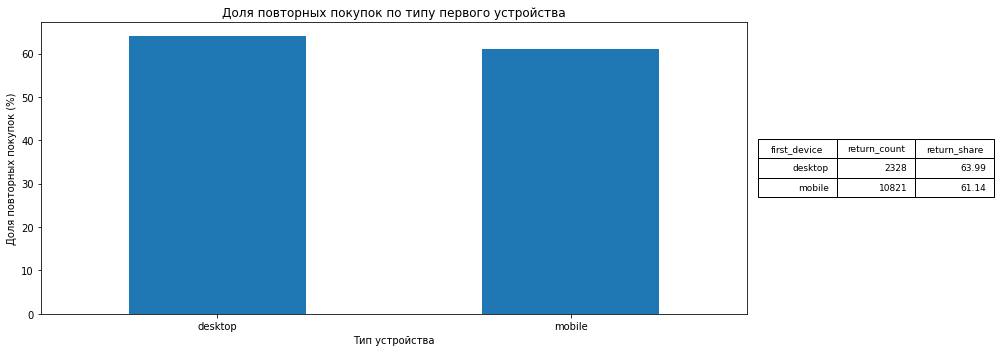

In [42]:
first_device_group_is_two = filtered_profile.groupby('first_device').agg(
                                    return_count=('is_two', 'sum'),
                                    return_share=('is_two', lambda x: round(x.mean() * 100, 2)))
    
device_df = first_device_group_is_two.sort_values('return_share', ascending=False).reset_index()



fig, (ax1, ax2) = plt.subplots(1, 2,
    figsize=(14, 5),
    gridspec_kw={'width_ratios': [3, 1]})


device_df.plot(
    kind='bar',
    x='first_device',
    y='return_share',
    ax=ax1,
    legend=False)

ax1.set_title('Доля повторных покупок по типу первого устройства')
ax1.set_xlabel('Тип устройства')
ax1.set_ylabel('Доля повторных покупок (%)')
ax1.tick_params(axis='x', rotation=0)

ax2.axis('off')

table = ax2.table(
    cellText=device_df.values,
    colLabels=device_df.columns,
    loc='center')

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.tight_layout()
plt.show()

Вычислим долю повтроных покупок в зависимости от типа первого региона

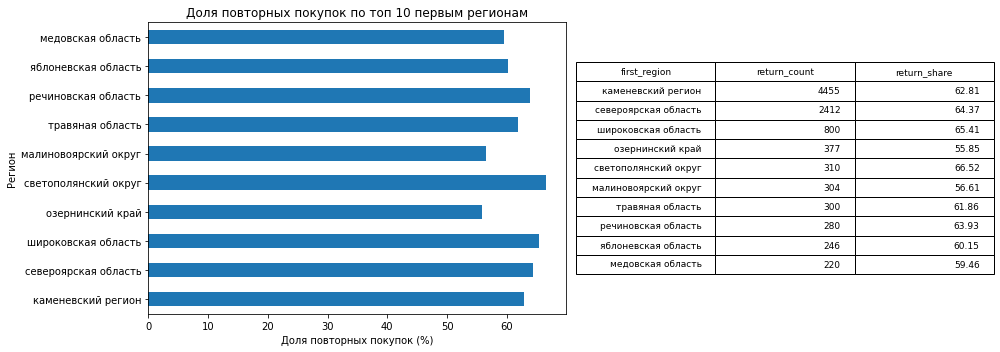

In [43]:
first_region_group_is_two = filtered_profile.groupby('first_region').agg(
                                    return_count=('is_two', 'sum'),
                                    return_share=('is_two', lambda x: round(x.mean() * 100, 2)))

    
region_df = (first_region_group_is_two
             .sort_values('return_count', ascending=False)
             .head(10)
             .reset_index()
            )

fig, (ax1, ax2) = plt.subplots(1, 2,
    figsize=(14, 5),
    gridspec_kw={'width_ratios': [2, 2]})


region_df.plot(
    kind='barh',
    x='first_region',
    y='return_share',
    ax=ax1,
    legend=False)

ax1.set_title('Доля повторных покупок по топ 10 первым регионам')
ax1.set_xlabel('Доля повторных покупок (%)')
ax1.set_ylabel('Регион')
ax1.tick_params(axis='x', rotation=0)

ax2.axis('off')

table = ax2.table(
    cellText=region_df.values,
    colLabels=region_df.columns,
    loc='center')

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.tight_layout()
plt.show()

Вычислим долю повтроных покупок в зависимости от первого организатора 

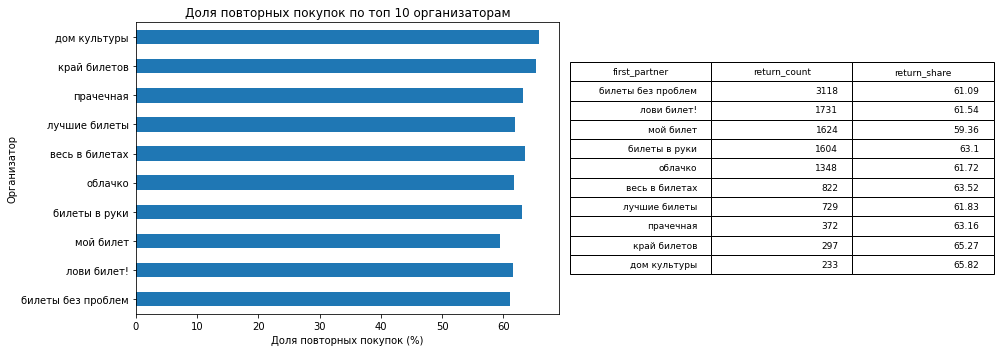

In [44]:
first_partner_group_is_two = filtered_profile.groupby('first_partner').agg(
                                    return_count=('is_two', 'sum'),
                                    return_share=('is_two', lambda x: round(x.mean() * 100, 2)))


    
partner_df = (first_partner_group_is_two
             .sort_values('return_count', ascending=False)
             .head(10)
             .reset_index()
            )

fig, (ax1, ax2) = plt.subplots(1, 2,
    figsize=(14, 5),
    gridspec_kw={'width_ratios': [2, 2]})


partner_df.plot(
    kind='barh',
    x='first_partner',
    y='return_share',
    ax=ax1,
    legend=False)

ax1.set_title('Доля повторных покупок по топ 10 организаторам')
ax1.set_xlabel('Доля повторных покупок (%)')
ax1.set_ylabel('Организатор')
ax1.tick_params(axis='x', rotation=0)

ax2.axis('off')

table = ax2.table(
    cellText=partner_df.values,
    colLabels=partner_df.columns,
    loc='center')

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.tight_layout()
plt.show()

Немного чаще возвращаются на Яндекс Афишу пользователи из следующих сегментов (с указанием доли вернувшихся):
* концерты - 63.8%
* desktop - 64.47%
* шанырский регион - 68.26%
* билеты без проблем - 65.23%<br>

Однако, стоит отметить, что внутри всех исследованных группах доли вернувшихся доволно близки.<br>
Также, стоит отметить, что среди регионов и организаторов между сегментами большой разброс по числу вернушихся клиентов (отличия более чем на порядок), что может искажать конечный результат.<br>
<br>
Выраженных «точек входа» не налблюдается.


---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---


Гипотеза 1 не подтвердилась. Пользователи, оформившие свой первый заказ на концерты возвращаются в 62.2% случаев, тогда как для спортивных мероприятий доля составила 56.2%.

Гипотеза 2 не подтвердилась. Зависимости повторных заказов от числа пользователей в регионе не прослеживается. 

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


Построим гистограмму распределения средней выручки с билета

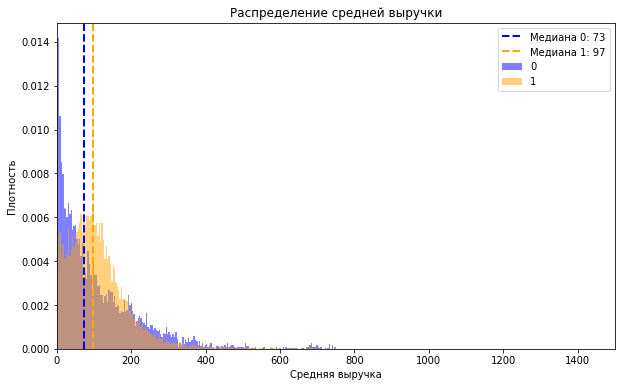

In [45]:
plt.figure(figsize=(10, 6))

colors = ['blue', 'orange']

for i, color in zip(filtered_profile['is_two'].unique(), colors):
    
    data = filtered_profile[filtered_profile['is_two'] == i]['avg_revenue_rub']
    
    median = data.median()
        
    data.plot(
        kind='hist',
        bins=200,
        alpha=0.5,
        label=f'{i}',
        legend=True,
        density=True,
        color=color
    )
        
    plt.axvline(
        median,
        linestyle='--',
        linewidth=2,
        color=color,
        label=f'Медиана {i}: {median:.0f}'
    )

plt.xlim(0, 1500)

plt.xlabel('Средняя выручка')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки')

plt.legend()
plt.show()

Ответы на вопросы задания:
* Для пользователей совершивших один заказ медиана средней выручки составила 73 руб.
* Для повторных пользователей медиана средней выручкисоставила 97 руб. <br>

Различия между группами есть, распределение совершивших один заказ имеет правосторонний скос с модой близкой к 0. В то время как пользователи с повторными заказами распределены более нормально, хотя также можно выделить две моды -  около 0 и около 100 руб.


---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


Строим распределение

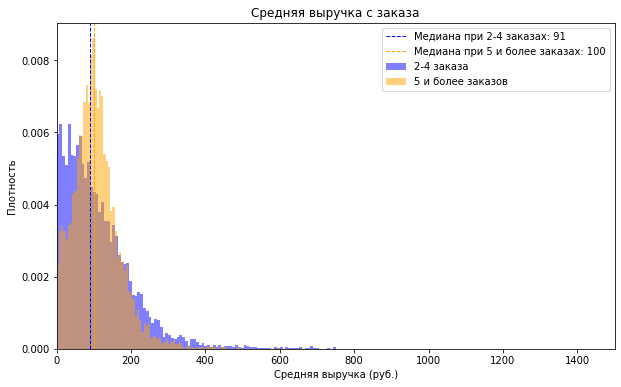

In [46]:
orders_2_4 = (filtered_profile
              [(filtered_profile['total_orders'] >= 2) & 
               (filtered_profile['total_orders'] <= 4)
              ]['avg_revenue_rub']
             )

orders_5_or_more = filtered_profile[filtered_profile['total_orders'] >= 5]['avg_revenue_rub']

median_2_4 = orders_2_4.median()
median_5_plus = orders_5_or_more.median()

plt.figure(figsize=(10, 6))

orders_2_4.plot(
    kind='hist',
    bins=100,
    alpha=0.5,
    density=True,
    label='2-4 заказа',
    color='blue')

orders_5_or_more.plot(
    kind='hist',
    bins=100,
    alpha=0.5,
    density=True,
    label='5 и более заказов',
    color='orange')

plt.axvline(
    median_2_4,
    linestyle='--',
    linewidth=1,
    color='blue',
    label=f'Медиана при 2-4 заказах: {median_2_4:.0f}')

plt.axvline(
    median_5_plus,
    linestyle='--',
    linewidth=1,
    color='orange',
    label=f'Медиана при 5 и более заказах: {median_5_plus:.0f}')


plt.title('Средняя выручка с заказа')
plt.xlabel('Средняя выручка (руб.)')
plt.ylabel('Плотность')
plt.xlim(0,1500)
plt.legend()
plt.show()

 Различия по значению средней выручки с заказа между пользователями незначительное. Медианные значения выручки составляют:
 * для группы 2-4 заказа - 91 руб.
 * для группы 5 и более - 100 руб.<br>
 
Но, как и на прудыдущем распределении, стоит отметить разнцу в форме распределения.<br>
* Для группы 2-4 заказа мода значения выручки находится около 0 руб., распределение имеет выраженный правосторонний скос.
* Тогда как для группы с 5 и более заказами моду близка к медиане, около 100 руб.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

Строим распределение пользователей по среднему количеству билетов в заказе

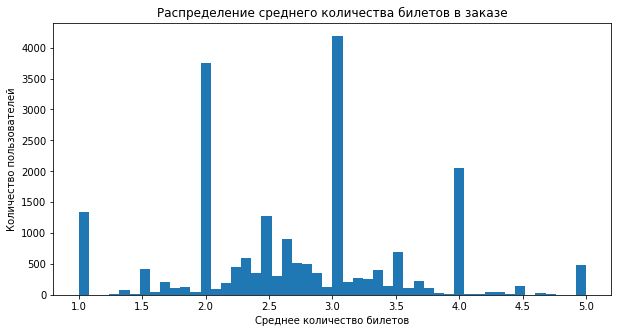

In [47]:
filtered_profile['avg_tickets'].plot(
    kind='hist',
    bins=50,
    figsize=(10, 5)
)

plt.title('Распределение среднего количества билетов в заказе')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Количество пользователей')

# plt.xlim(0, 10)

plt.show()

Создадим столбец tickets_segment сегментирующий пользователей по среднему количеству билетов в заказе

In [48]:
filtered_profile['tickets_segment'] = pd.cut(
    filtered_profile['avg_tickets'],
    bins=[1, 2, 3, 5, 1000],
    labels=[
        '1–2 билета',
        '2–3 билета',
        '3–5 билетов',
        '5+ билетов'
    ],
    right=False
)

Вычислим метрики из задачи

In [49]:
tickets_group = (filtered_profile.groupby('tickets_segment')
    .agg(
        users_count=('user_id', 'nunique'),
        return_count=('is_two', 'sum'),
        return_share=('is_two', lambda x: round(x.mean() * 100, 2))
    ).reset_index()
)

tickets_group

,tickets_segment,users_count,return_count,return_share
0,1–2 билета,2420,1241,51.28
1,2–3 билета,9405,6894,73.30
2,3–5 билетов,9031,4949,54.80
3,5+ билетов,480,65,13.54


Отразим на диаграмме долю повторных покупок по билетным сегментам

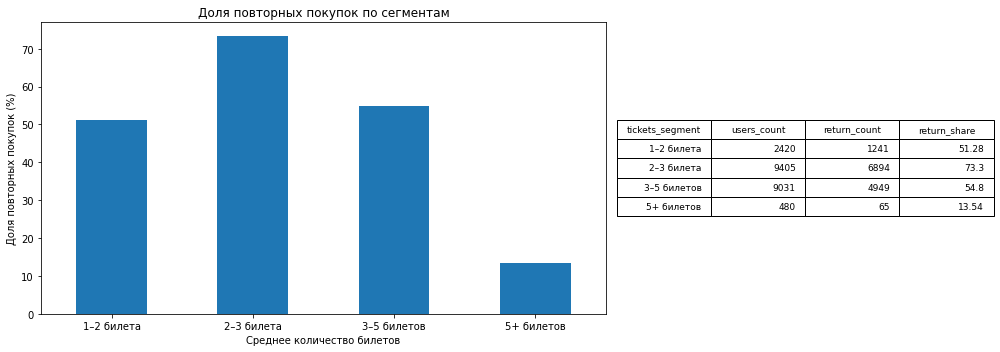

In [50]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    gridspec_kw={'width_ratios': [6, 4]}
)

tickets_group.plot(
    kind='bar',
    x='tickets_segment',
    y='return_share',
    ax=ax1,
    legend=False
)

ax1.set_title('Доля повторных покупок по сегментам')
ax1.set_xlabel('Среднее количество билетов')
ax1.set_ylabel('Доля повторных покупок (%)')
ax1.tick_params(axis='x', rotation=0)

ax2.axis('off')

table = ax2.table(
    cellText=tickets_group.values,
    colLabels=tickets_group.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.tight_layout()
plt.show()

Ответы на вопросы задания:
* Пользователи по сегментам распределены неравномерно. Примерно по 9.4 тыс. пользователей находятся в сегментах "2-3 билета" и в этом же сегменте наиболшая доля повторных покупок - 73.3%. В то же время сегмент "5+ билетов" содержится лишь 480 пользователей с долей повторных покупок 13.5%.
* Такие доли повторных покупок вполне ожидаемы  и не выглядят необычно


---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


Создадим столбец first_order_weekday содержащий дни недели в числовом формате.

In [51]:
filtered_profile['first_order_weekday'] = filtered_profile['first_order'].dt.weekday


Вычислим необходимые метрики

In [52]:
weekday_group = (
    filtered_profile.groupby('first_order_weekday')
    .agg(
        users_count=('user_id', 'nunique'),
        return_count=('is_two', 'sum'),
        return_share=('is_two', lambda x: round(x.mean() * 100, 2))
    ).reset_index()
)

Отобразим результат на диаграмме

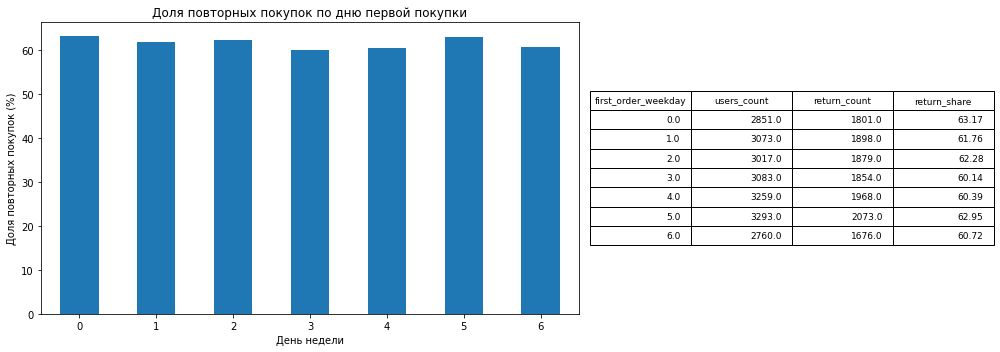

In [53]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    gridspec_kw={'width_ratios': [4, 3]}
)

weekday_group.plot(
    kind='bar',
    x='first_order_weekday',
    y='return_share',
    ax=ax1,
    legend=False
)

ax1.set_title('Доля повторных покупок по дню первой покупки')
ax1.set_xlabel('День недели')
ax1.set_ylabel('Доля повторных покупок (%)')
ax1.tick_params(axis='x', rotation=0)

ax2.axis('off')

table = ax2.table(
    cellText=weekday_group.values,
    colLabels=weekday_group.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.tight_layout()
plt.show()

Ответ на вопрос задания:
* День недели первой покупки не влияет на вероятность повторной покупки. Для всех дней недели доля повторных покупок около 60%.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


Создадим столбец avg_time_diff_days

In [54]:
filtered_profile['avg_time_diff_days'] = filtered_profile['avg_time_diff'].dt.days

orders_2_4 = filtered_profile[
    (filtered_profile['total_orders'] >= 2) &
    (filtered_profile['total_orders'] <= 4)
]['avg_time_diff_days']

orders_5_plus = filtered_profile[filtered_profile['total_orders'] >= 5]['avg_time_diff_days']

Отразим результат на гистограмме

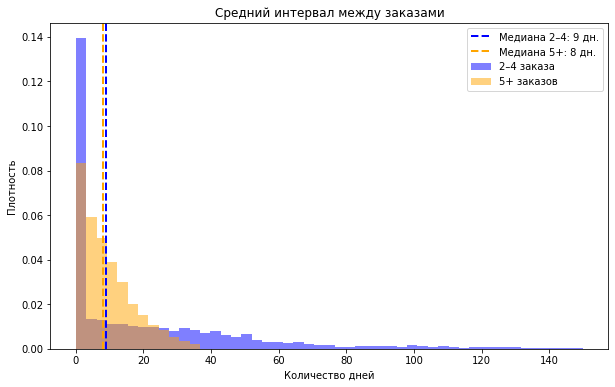

In [55]:
bins = np.linspace(0, 150, 50)
plt.figure(figsize=(10, 6))

orders_2_4.plot(
    kind='hist',
    bins=bins,
    alpha=0.5,
    density=True,
    label='2–4 заказа',
    color='blue'
)

orders_5_plus.plot(
    kind='hist',
    bins=bins,
    alpha=0.5,
    density=True,
    label='5+ заказов',
    color='orange'
)

plt.axvline(
    orders_2_4.median(),
    linestyle='--',
    linewidth=2,
    color='blue',
    label=f'Медиана 2–4: {orders_2_4.median():.0f} дн.'
)

plt.axvline(
    orders_5_plus.median(),
    linestyle='--',
    linewidth=2,
    color='orange',
    label=f'Медиана 5+: {orders_5_plus.median():.0f} дн.'
)

plt.title('Средний интервал между заказами')
plt.xlabel('Количество дней')
plt.ylabel('Плотность')
plt.legend()
plt.show()

* Различия между группами нельзя назвать очень большими, медиана среднего интервала между заказами составляет 9 дней для группы "2-4 заказа" и 8 дней в группе "5+ заказов". 
* Однако в глаза бросается выраженная неравномерность распределения в группе "2-4 заказа", мода равна 0 дней, т.е. заказы совершены в один день. Для группы "5+ заказов" мода также равно 0 дней но таких интервалов в два раза меньше, а остальные данные равномернее распределены вдоль временной шкалы по оси Х.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

Выделим сегменты пользователей по полю total_orders

In [56]:
filtered_profile['orders_segment'] = pd.cut(
    filtered_profile['total_orders'],
    bins=[0, 1, 4, 1000],
    labels=[
        '1 заказ',
        '2–4 заказа',
        '5+ заказов'
    ]
)

In [57]:
corr_df = filtered_profile[
    [
        'orders_segment',
        'avg_revenue_rub',
        'avg_tickets',
        'avg_time_diff_days',
        'first_device',
        'first_region',
        'first_partner',
        'first_genre'
    ]
]

In [58]:
phik_corr = corr_df.phik_matrix(
    interval_cols=[
        'avg_revenue_rub',
        'avg_tickets',
        'avg_time_diff_days'
    ]
)

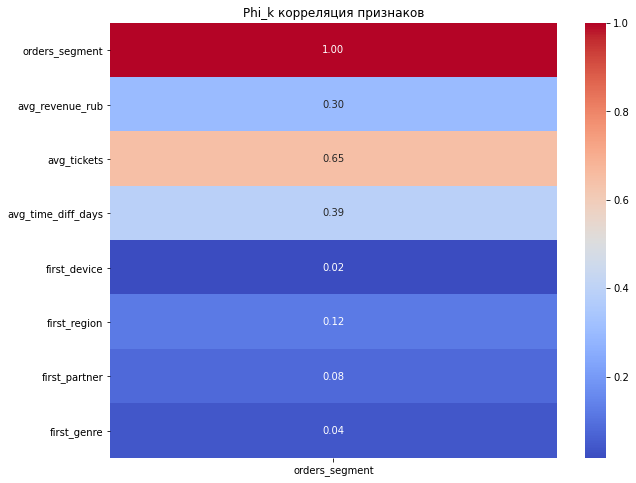

In [59]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    phik_corr[['orders_segment']],
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Phi_k корреляция признаков')
plt.show()

По результатам анализа можно выделить следующие признаки имеющие наибольшую корреляцию с количеством заказов:
* среднее число билетов в заказе (0.65) 
* среднее число дней между заказами (0.39). Тут возможна неточность, т.к. при 1 avg_time_diff отсутствует вовсе.
* средняя выручка с заказа (0.30)

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**Общий вывод**<br>
Информацияо данных:
* Данные получены из сервиса Яндекс Афиша. Изначальный датасет содержал 290611 строк и 15 столбцов для 21933 пользователей.
* На этапе предобработки данных:
    * Выручка приведена к единой валюте — российскому рублю
    * Оптимизировано использование числовых данных
    * Нормализованы номинальные данные, проверены на дубликаты
    * Выручка с заказа и количество билетов в заказе отфильтрованы по 99 перцентилю, исключены отрицательные значения выручки
    * Создан профиль пользователя
    * Отфильтрованы пользователи с аномальным числом билетов<br>
    * Удалено пользователей: 407 (1.87%), это допустимый объем потерь не приводящий к значимым искажениям дальнейшего анализа.<br>


* Исследовательский анализ данных показал следующее:
    * Общее число пользователей: 21336
    * Средняя выручка с одного заказа: 104.16 руб.
    * Доля пользователей с 2+ заказами: 61.63%
    * Доля пользователей с 5+ заказами: 28.57%
    * Имеются выраженные "точки входа" для первого заказа:
        * по типу мероприятия - это концерты 44.44%
        * по типу устройства - это мобильные устройства 82.72%
        * по региону - это Каменевский регион 32.89%
        * по организатору - это "Билеты без проблем" 23.72%
    * Вывраженных "точек входа" для повторных заказов не выявлено
    * Пользователи с повторными заказами приносят большую выручку (медиана 97 руб./заказ) по сравнению с пользователями с одним заказом (медиана 73 руб./заказ)
    * Больше всего пользователей с заказами по 2–3 билета (n=9405) с долей повторных заказов 73.3%
    * Выраженная неравномерность распределения для группы с 2-4 заказами, мода равна 0 дней, т.е. заказы совершены в один день
    * Набольший коэфициент корреляции числа заказов наблюдается для среднего числа билетов в заказе (phi_k=0.65), среднего числа дней между заказами (phi_k=0.39) и средней выручкы с заказа (phi_k=0.30)
    



### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**

Ссылка на проект:
https://github.com/zernovnv/module_2_project.git